In [1]:
from datetime import datetime

import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt

from src.saws_functions import release_points_from_SaWS_images  # noqa: E402

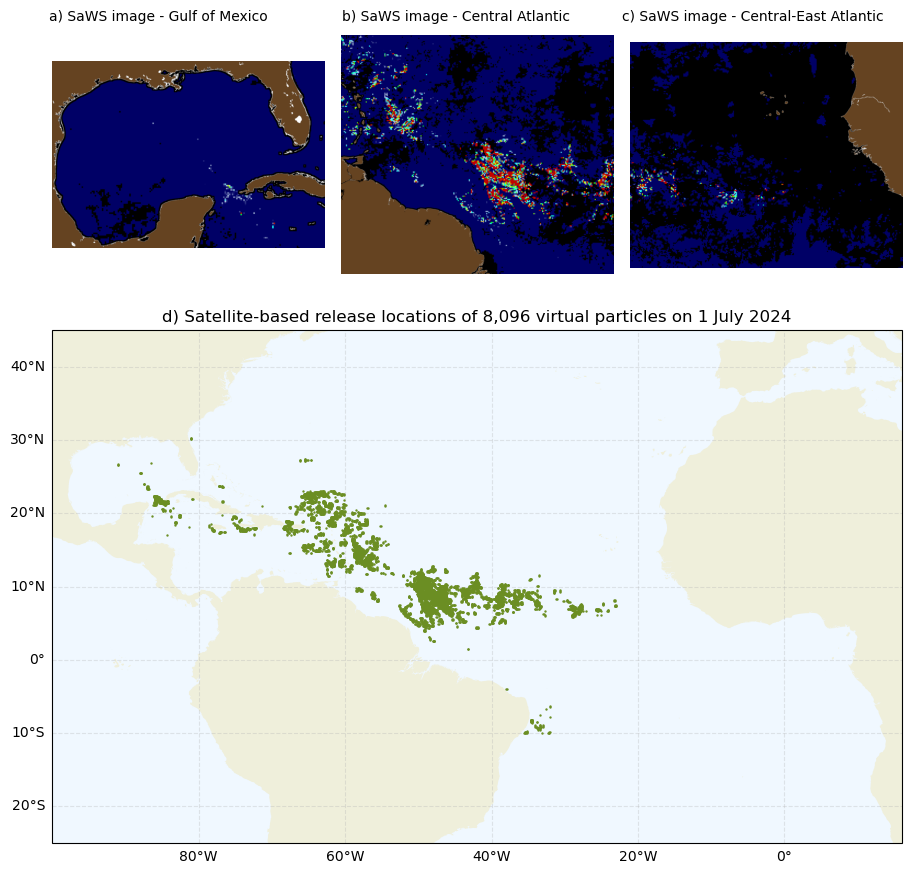

In [2]:
#Loading satellite images
coords = release_points_from_SaWS_images(datetime(2024,7,1), stride=8)

images = [
    plt.imread('SaWS_downloads/C20241772024183.1KM.GCOOS.7DAY.L3D.FA_UNET_DENSITY.png'),
    plt.imread('SaWS_downloads/C20241772024183.1KM.C_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png'),
    plt.imread('SaWS_downloads/C20241772024183.1KM.CE_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png'),
]

# Calculate aspect ratios and scale images to consistent PPI
target_width = 3.0  # inches per image
aspect_ratios = [img.shape[1] / img.shape[0] for img in images]  # width / height
heights = [target_width / ar for ar in aspect_ratios]

# Figure dimensions based on scaled image sizes
total_width = target_width * 3
max_height = max(heights)
fig_height = max_height + 6  # top images + bottom map

#Creating figure layout: top row = 3 PNG images, bottom row = map
fig = plt.figure(figsize=(total_width, fig_height), constrained_layout=True)
gs = fig.add_gridspec(2, 3, height_ratios=[max_height, 6])

#Top-left: Gulf of Mexico PNG
ax0 = fig.add_subplot(gs[0, 0])
ax0.imshow(images[0])
ax0.axis('off')

#Top-center: Central Atlantic PNG
ax1 = fig.add_subplot(gs[0, 1])
ax1.imshow(images[1])
ax1.axis('off')

#Top-right: Central-East Atlantic PNG
ax2 = fig.add_subplot(gs[0, 2])
ax2.imshow(images[2])
ax2.axis('off')

# Align titles on top using fig.text for absolute positioning
title_y = 1
fig.text(0.17, title_y, 'a) SaWS image - Gulf of Mexico', ha='center')
fig.text(0.5, title_y, 'b) SaWS image - Central Atlantic', ha='center')
fig.text(0.83, title_y, 'c) SaWS image - Central-East Atlantic', ha='center')

#Bottom row: map spanning all columns
ax3 = fig.add_subplot(gs[1, :], projection=ccrs.PlateCarree())
ax3.set_facecolor('aliceblue')
ax3.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=1)
ax3.gridlines(draw_labels=['left', 'bottom'], zorder=0, alpha=0.3, linestyle='--')
ax3.scatter(coords[:, 0], coords[:, 1], s=0.5, color='olivedrab', zorder=5)
ax3.set_extent([-100, 16, -25, 45], crs=ccrs.PlateCarree())
ax3.set_title(f'd) Satellite-based release locations of {len(coords):,} virtual particles on 1 July 2024')

fig.savefig('Figures/Figure1.png', bbox_inches='tight', dpi=300)

plt.show()